In [16]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest , GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw , integrated_brier_score
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import category_encoders as ce
import mygene
from sklearn.preprocessing import MultiLabelBinarizer
import re

# MOLECULAR DATAFRAME

In [39]:
mol_df = pl.read_csv("../data/raw/X_test/molecular_test.csv" , ignore_errors=True)

mol_df


ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
str,i64,f64,f64,str,str,str,str,str,f64,f64
"""KYW961""",1,1.747229e6,1.747229e6,"""T""","""C""","""GNB1""","""p.K57E""","""non_synonymous_codon""",0.262,485.0
"""KYW142""",1,1.747229e6,1.747229e6,"""T""","""C""","""GNB1""","""p.K57E""","""non_synonymous_codon""",0.028,527.0
"""KYW453""",1,1.747229e6,1.747229e6,"""T""","""C""","""GNB1""","""p.K57E""","""non_synonymous_codon""",0.292,277.0
"""KYW982""",1,1.747229e6,1.747229e6,"""T""","""C""","""GNB1""","""p.K57E""","""non_synonymous_codon""",0.097,821.0
"""KYW845""",1,3.6932209e7,3.6932209e7,"""G""","""A""","""CSF3R""","""p.Q754X""","""stop_gained""",0.43,358.0
…,…,…,…,…,…,…,…,…,…,…
"""KYW1077""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",0.4231,null
"""KYW1084""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",0.0176,null
"""KYW1082""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",0.2273,null


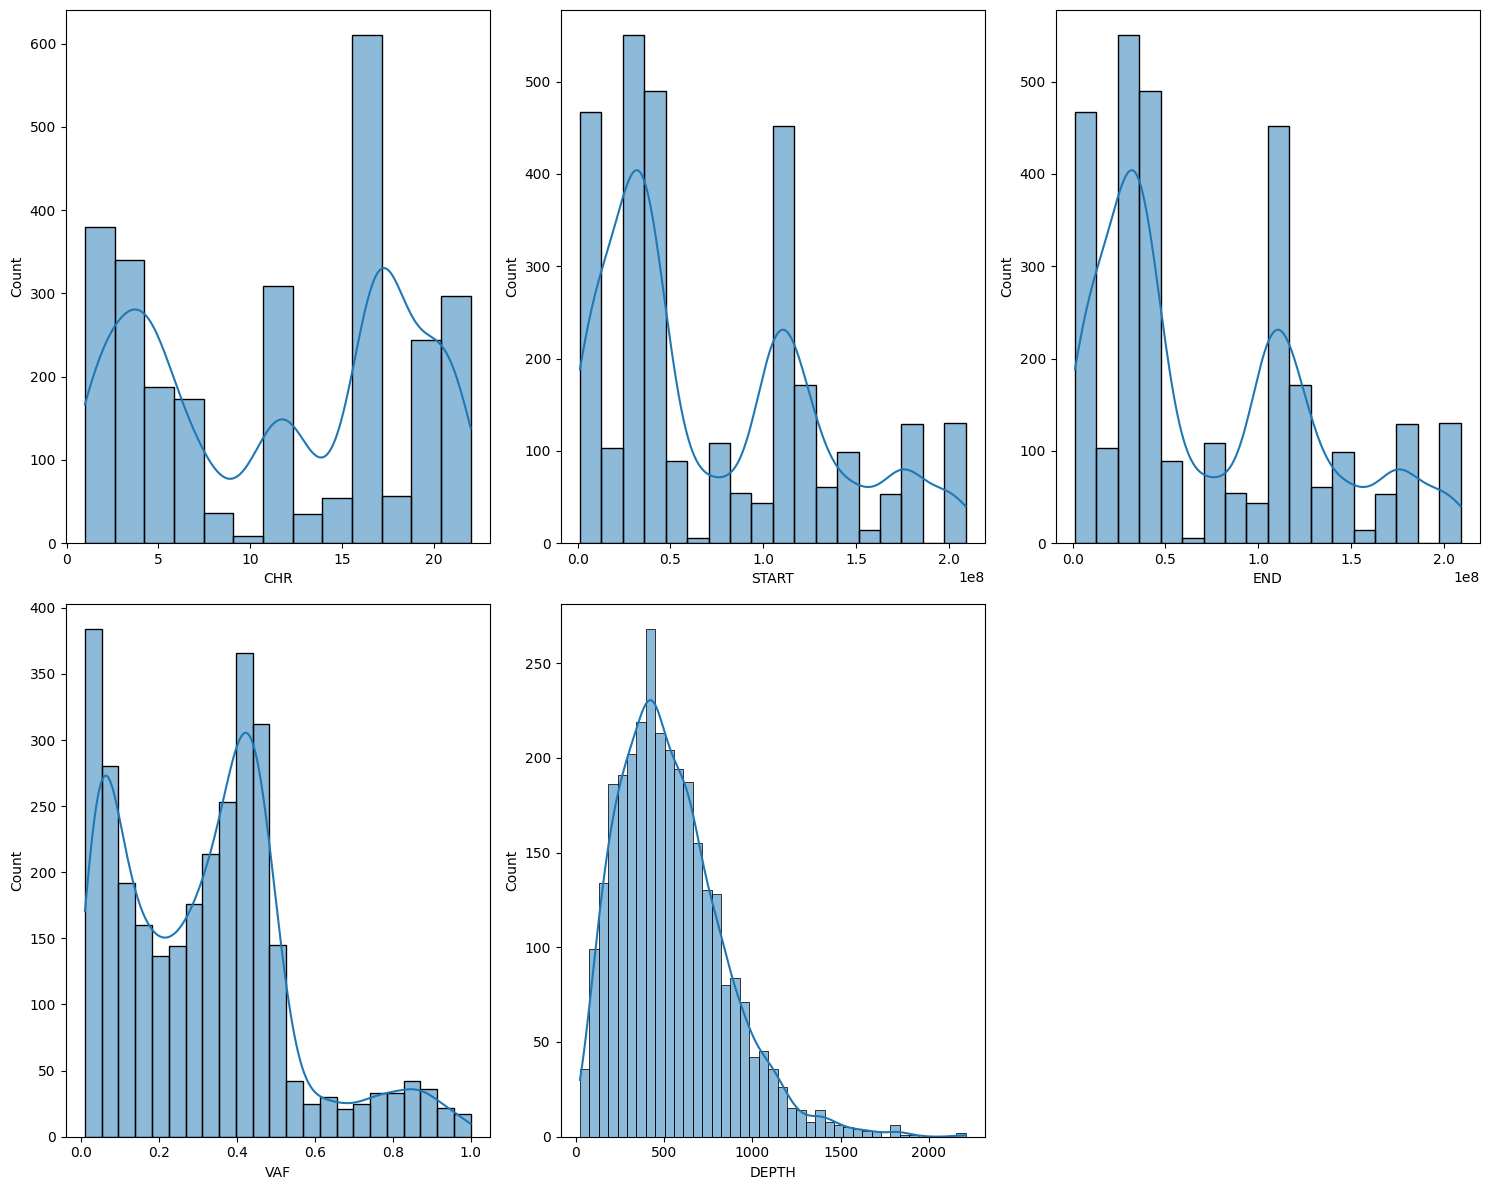

In [7]:
import math

col_int = [col for (col , dtype) in zip(mol_df.columns,mol_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]


num_cols = len(col_int)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize = (15,12))


for i, cols in enumerate(col_int , 1):
    plt.subplot(num_rows,3,i)
    sns.histplot(data = mol_df,x = cols,kde = True)
plt.tight_layout()
plt.show()

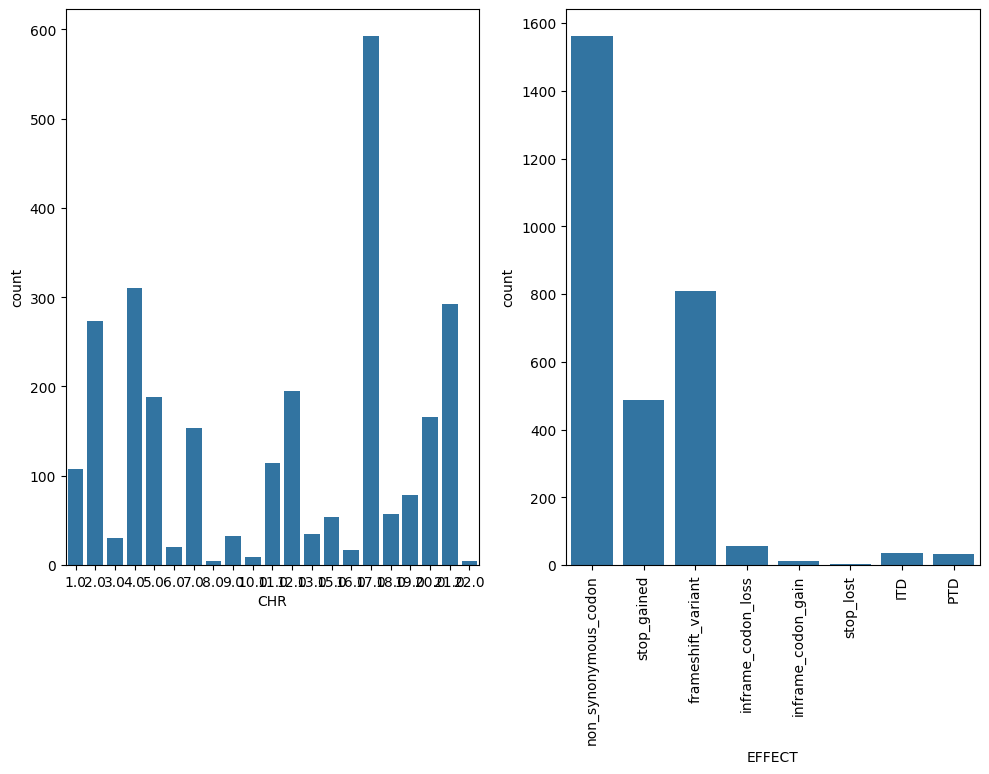

In [9]:
import math

categorical_col = ["CHR" , "EFFECT"]

num_cols = len(col_int)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize = (15,12))


for i, cols in enumerate(categorical_col , 1):
    plt.subplot(num_rows,3,i)
    sns.countplot(data = mol_df , x=cols)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [8]:

def to_int(chromosome_str):
    """
    Convert chromosome identifier to integer.
    
    Parameters:
    -----------
    chromosome_str : str
        Chromosome identifier (e.g., '1', '2', 'X')
        
    Returns:
    --------
    int
        Integer representation of chromosome (X is converted to 23)
        
    Raises:
    -------
    ValueError
        If input is not a string or cannot be converted to integer
    """
    if not isinstance(chromosome_str, str):
        raise ValueError("Input must be a string")
        
    if chromosome_str.upper() == 'X':
        return 23  # X chromosome is represented as 23
    else:
        try:
            return int(chromosome_str)
        except ValueError:
            raise ValueError(f"Cannot convert '{chromosome_str}' to integer")
    


    
def chr_to_int(df, column_name="CHR"):
    """
    Convert chromosome identifiers in a dataframe column to integers.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing chromosome data
    column_name : str, default="CHR"
        Column name containing chromosome identifiers

    Returns:
    --------
    pl.DataFrame
        DataFrame with chromosome identifiers converted to integers

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    try:
        df = df.with_columns(
            pl.col(column_name).map_elements(to_int, return_dtype=pl.Int64)
            .alias(column_name)
        )
        return df
    except Exception as e:
        raise ValueError(f"Error converting chromosome to integer: {str(e)}")
    


def dna_to_array(dna_sequence):
    """
    Convert DNA sequence to array of nucleotides, replacing non-standard bases with 'n'.

    Parameters:
    -----------
    dna_sequence : str
        DNA sequence string

    Returns:
    --------
    list
        List of nucleotides ('a', 'g', 't', 'c', or 'n')
    """
    if not isinstance(dna_sequence, str):
        raise ValueError("DNA sequence must be a string")

    nitrogen_bases = ['a', 'g', 't', 'c']
    dna_sequence = dna_sequence.lower()

    return [ch if ch in nitrogen_bases else 'n' for ch in dna_sequence]




def ordinal_encoder_dna(dna_sequence):
    """
    Encode DNA sequence as numerical values.

    Parameters:
    -----------
    dna_sequence : str or list
        DNA sequence as string or list of nucleotides

    Returns:
    --------
    list
        List of numerical values (a=0.25, c=0.5, g=0.75, t=1.0, other=0.0)
    """
    if isinstance(dna_sequence, str):
        dna_sequence = dna_to_array(dna_sequence)

    mapping = {'a': 0.25, 'c': 0.5, 'g': 0.75, 't': 1.00}

    return [mapping.get(x, 0.0) for x in dna_sequence]



def extract_kmers(sequence, k):
    """
    Extract k-mers from a sequence.

    Parameters:
    -----------
    sequence : str
        Input sequence
    k : int
        Length of k-mers

    Returns:
    --------
    list
        List of k-mers

    Raises:
    -------
    ValueError
        If k is larger than sequence length or not a positive integer
    """
    if not isinstance(sequence, str):
        raise ValueError("Sequence must be a string")

    if not isinstance(k, int) or k <= 0:
        raise ValueError("k must be a positive integer")

    if k > len(sequence):
        raise ValueError(f"k ({k}) cannot be larger than sequence length ({len(sequence)})")

    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]


def join_str(str):
    return ' '.join(str)



def gene_new_name(df, column_name):
    """
    Update gene names to their current nomenclature.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing gene names
    column_name : str
        Column name containing gene identifiers

    Returns:
    --------
    pl.DataFrame
        DataFrame with updated gene names

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")


    # Mapping of old gene names to current nomenclature
    mapping = {
        'MLL': 'KMT2A',      # Mixed-lineage leukemia -> Lysine methyltransferase 2A
        'WHSC1': 'NSD2',     # Wolf-Hirschhorn syndrome candidate 1 -> Nuclear SET domain-containing protein 2
        'H3F3A': 'H3-3A',    # H3 histone family member 3A -> Histone H3.3
        'FAM175A': 'ABRAXAS1', # Family with sequence similarity 175 member A -> BRCA1-A complex subunit Abraxas 1
        'PAPD5': 'TENT4B'    # PAP associated domain containing 5 -> Terminal nucleotidyltransferase 4B
    }

    try:
        df = df.with_columns(
            pl.col(column_name).map_elements(lambda g: mapping.get(g, g)).alias(column_name)
        )
        return df
    except Exception as e:
        raise ValueError(f"Error updating gene names: {str(e)}")


def cytogenetics(df, column_name):
    """
    Retrieve gene ontology information for genes in the dataframe.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing gene names
    column_name : str
        Column name containing gene identifiers

    Returns:
    --------
    list
        List of gene ontology results

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    genes = list(df[column_name].unique())

    try:
        mg = mygene.MyGeneInfo()
        results = mg.querymany(genes, scopes="symbol", fields='go', species="human", timeout=30)
        return results
    except Exception as e:
        print(f"Warning: Failed to retrieve gene ontology data: {e}")
        return []


def genes_to_go(results_cyto):
    """
    Extract gene ontology terms from mygene results.

    Parameters:
    -----------
    results_cyto : list
        List of gene ontology results from mygene

    Returns:
    --------
    dict
        Dictionary mapping gene symbols to GO term IDs
    """
    if not results_cyto:
        return {}

    gene_to_go = {}
    for res in results_cyto:
        gene = res.get('query')
        go_bp = res.get('go', {}).get('BP', [])

        # Handle case where go_bp is a dictionary (single term)
        if isinstance(go_bp, dict):
            go_bp = [go_bp]

        go_terms = [go['id'] for go in go_bp if 'id' in go]

        if gene and go_terms:
            gene_to_go[gene] = go_terms

    return gene_to_go


def multi_label_gene_go(gene_to_go, min_gene_count=5):
    """
    Create a binary matrix of genes and GO terms.

    Parameters:
    -----------
    gene_to_go : dict
        Dictionary mapping gene symbols to GO term IDs
    min_gene_count : int, default=5
        Minimum number of genes required for a GO term to be included

    Returns:
    --------
    pd.DataFrame
        Binary matrix with genes as index and GO terms as columns
    """
    if not gene_to_go:
        return pd.DataFrame()

    # Create binary matrix
    mlb = MultiLabelBinarizer()
    go_matrix = mlb.fit_transform(gene_to_go.values())
    go_df = pd.DataFrame(go_matrix, index=gene_to_go.keys(), columns=mlb.classes_)

    # Filter GO terms by frequency
    filtered_go_df = go_df.loc[:, (go_df.sum(axis=0) >= min_gene_count)]

    return filtered_go_df




def merge_df(df, filtered_go_df, join_column, join_type="left"):
    """
    Merge dataframe with GO terms dataframe.

    Parameters:
    -----------
    df : pl.DataFrame
        Main dataframe
    filtered_go_df : pd.DataFrame
        DataFrame with GO terms
    join_column : str
        Column name to join on
    join_type : str, default="left"
        Type of join to perform

    Returns:
    --------
    pl.DataFrame
        Merged dataframe

    Raises:
    -------
    ValueError
        If input dataframes are invalid or join column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("First dataframe must be a Polars DataFrame")

    if not isinstance(filtered_go_df, pd.DataFrame):
        raise ValueError("Second dataframe must be a Pandas DataFrame")

    if join_column not in df.columns:
        raise ValueError(f"Join column '{join_column}' not found in first DataFrame")

    if filtered_go_df.empty:
        return df

    try:
        # Convert to pandas for merge
        df_pd = df.to_pandas()

        # Merge dataframes
        df_merged = df_pd.merge(filtered_go_df, left_on=join_column, right_index=True, how=join_type)

        # Convert back to polars
        return pl.from_pandas(df_merged)
    except Exception as e:
        raise ValueError(f"Error merging dataframes: {str(e)}")




def protein_name(protein_changes, ch):
    lst_prot = []
    pattern = rf"p\.{ch}\d+.*"

    for prot in protein_changes:
        if isinstance(prot, str): 
            prot_name = re.findall(pattern, prot)
            if prot_name:
                lst_prot+=prot_name
                
    return lst_prot


def get_protein_dico(uppercase_alphabet , lst , aa_fullname):
    dico_protein_changes = {}
        
    for ch in uppercase_alphabet:
        if(len(lst) >=1):
            ch_name = aa_fullname.get(ch)
            dico_protein_changes[ch_name] = lst
            
    return dico_protein_changes


def protein_type(df , protein_change , dico_protein_changes):
    acide_aminee = {}

    for elem in protein_change:
        for aa_name , mutations in dico_protein_changes.items():
            if elem in mutations:
                acide_aminee[elem] = aa_name
                
                          
    # KMT2A => MLL PTD => Lysine 
    # FLT3-ID => FLT3 => tyrosine

    acide_aminee["MLL_PTD"] = "Lysine"
    acide_aminee["FLT3_ITD"] = "Tyrosine"
    acide_aminee["p.?"] = "Unknown"
    
    df = df.with_columns(
        pl.col("PROTEIN_CHANGE").map_elements(lambda x: acide_aminee.get(x, None)).alias("AA_TYPE")
    )
                
    return acide_aminee , df


def remove_row_element(df , col , lst):

    for elem in lst:
        df = df.remove(pl.col(col) == elem)
        
    return df


def drop_null_subset(df, subset):
    df = df.drop_nulls(subset=subset)
    
    return df


def is_protein_unknown(df):
    df = df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE") == "p.?")
        .then(1)
        .otherwise(0)
        .alias("IS_PT_UKNOWN")
    )
    
    return df

def is_frameshift(df):
    df = df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE").str.contains('fs'))
        .then(1)
        .otherwise(0)
        .alias("is_frameshift")
    )
    
    return df

def is_non_sens(df):
    #NON_SENS_MUTATION
    df = df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE").str.contains("\*"))
        .then(1)
        .otherwise(0)
        .alias("is_non_sens_mutation")
    )
    
    return df


def is_missense(protein_change):
    """
    Check if a protein change is a missense mutation.

    Parameters:
    -----------
    protein_change : str
        Protein change annotation

    Returns:
    --------
    int
        1 if missense mutation, 0 otherwise
    """
    if protein_change is not None and isinstance(protein_change, str):
        # Check if it's a missense mutation (starts with p. and ends with amino acid letter)
        if (protein_change.startswith("p.") and
            protein_change[-1].isalpha() and
            "*" not in protein_change and
            "fs" not in protein_change):
            return 1
    return 0


def is_SNV(df , col , letter):
    df = df.with_columns(
        pl.when(pl.col(col) == letter)
        .then(1)
        .otherwise(0)
        .alias(f"{col}_is_SNV_{letter}")
    )
    
    return df




def complex_nucleotide(df , col ):
    df = df.with_columns(
        pl.when(pl.col(col).str.len_chars() > 1)
        .then(1)
        .otherwise(0)
        .alias(f"complex_nucleotide_{col}")
    )
    
    return df


def is_transition(str1, str2):
    if isinstance(str1, str) and isinstance(str2, str):
        if (str1 == "A" and str2 == "G") or (str1 == "G" and str2 == "A"):
            return 1
        elif (str1 == "C" and str2 == "T") or (str1 == "T" and str2 == "C"):
            return 1
    return 0

def is_transversion(str1, str2):
    if isinstance(str1, str) and isinstance(str2, str):
        trans_vers = {
            ("A", "C"), ("C", "A"), ("C", "G"), ("G", "C"),
            ("G", "T"), ("T", "G"), ("A", "T"), ("T", "A")
        }
        return int((str1, str2) in trans_vers)
    return 0

def is_indel(str1, str2):
    if isinstance(str1, str) and isinstance(str2, str):
        return int(len(str1) != len(str2))
    return 0



def add_mutation_density_features(df):
    """
    Add mutation density features to the molecular dataframe.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing mutation data

    Returns:
    --------
    pl.DataFrame
        DataFrame with added mutation density features

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or required columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    required_columns = ["GENE", "EFFECT", "CHR", "START"]
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(f"Missing required columns: {', '.join(missing_columns)}")

    try:
        # Count mutations per gene
        gene_counts = df.group_by("GENE").agg(
            pl.len().alias("mutations_per_gene")
        )

        # Count mutations per gene and effect type
        gene_effect_counts = df.group_by(["GENE", "EFFECT"]).agg(
            pl.len().alias("mutations_per_gene_effect")
        )

        # Count mutations per chromosome region
        region_counts = df.group_by(["CHR", "START"]).agg(
            pl.len().alias("mutations_per_region")
        )

        # Join counts back to the original dataframe
        df = df.join(gene_counts, on="GENE", how="left")
        df = df.join(gene_effect_counts, on=["GENE", "EFFECT"], how="left")
        df = df.join(region_counts, on=["CHR", "START"], how="left")

        return df
    except Exception as e:
        raise ValueError(f"Error adding mutation density features: {str(e)}")


<>:444: SyntaxWarning: invalid escape sequence '\*'
<>:444: SyntaxWarning: invalid escape sequence '\*'
C:\Users\zakar\AppData\Local\Temp\ipykernel_3632\1520793606.py:444: SyntaxWarning: invalid escape sequence '\*'
  pl.when(pl.col("PROTEIN_CHANGE").str.contains("\*"))


In [10]:
def binary_encoder(df, cl_lst):
    df_pd = df.to_pandas()
    
    encoder = ce.BinaryEncoder(cols=cl_lst)
    df_encoded = encoder.fit_transform(df_pd)
    
    return pl.from_pandas(df_encoded)

def imputation_null_values(df, column_list, estimator=None):
    """
    Impute missing values using iterative imputation.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns with missing values
    column_list : list
        List of column names to impute
    estimator : object, default=None
        Estimator for IterativeImputer (defaults to RandomForestRegressor if None)

    Returns:
    --------
    pl.DataFrame
        DataFrame with imputed values

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for imputation: {', '.join(missing_columns)}")

    # Check if there are any null values to impute
    null_counts = {col: df.select(pl.col(col).is_null().sum())[0, 0] for col in column_list}
    if sum(null_counts.values()) == 0:
        return df  # No nulls to impute

    try:
        # Select subset of dataframe
        sub_df = df.select(column_list)

        # Convert to pandas
        sub_pd = sub_df.to_pandas()
        

        # Apply imputation
        imputer = IterativeImputer(estimator=estimator, random_state=42)
        imputed_data = imputer.fit_transform(sub_pd)

        # Convert back to polars
        imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

        # Replace nulls in original dataframe
        df = df.with_columns([imputed_pl[col].alias(col) for col in column_list])

        return df
    except Exception as e:
        raise ValueError(f"Error during imputation: {str(e)}")
    

def iqr_method(df , cl_lst):

    for (index , cl )  in enumerate(cl_lst):
        q1 = df.select(pl.col(cl).quantile(0.25)).item()
        q3 = df.select(pl.col(cl).quantile(0.75)).item()
        
        iqr = q3 - q1
        
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        
        # Winsorisation : capped values
        df = df.with_columns(
            pl.when(pl.col(cl) < lower_bound).then(lower_bound)
            .when(pl.col(cl) > upper_bound).then(upper_bound)
            .otherwise(pl.col(cl))
            .alias(cl)
        )
        
        
        
    return df

def min_max_normalization(df, column_list):
    """
    Apply min-max normalization to specified columns.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns to normalize
    column_list : list
        List of column names to normalize

    Returns:
    --------
    pl.DataFrame
        DataFrame with normalized columns

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for normalization: {', '.join(missing_columns)}")

    try:
        for col in column_list:
            min_val = df[col].min()
            max_val = df[col].max()

            # Avoid division by zero
            if min_val == max_val:
                df = df.with_columns(
                    pl.lit(0.5).alias(col)
                )
            else:
                df = df.with_columns(
                    ((pl.col(col) - min_val)/(max_val - min_val)).alias(col)
                )

        return df
    except Exception as e:
        raise ValueError(f"Error during min-max normalization: {str(e)}")
    
def map_lambda(df , col , new_name , function , return_type):
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: function(x) , return_dtype=return_type)
        .alias(new_name)
    )
    
    return df


def map_row(df, col1, col2, new_name, function, return_type):
    return df.with_columns(
        pl.struct([col1, col2]).map_elements(
            lambda row: function(row[col1], row[col2]), return_dtype=return_type
        ).alias(new_name)
    )

In [15]:
from sklearn.tree import DecisionTreeRegressor
import re


def process_molecular_data(mol_df):
    
    # Validate input
    if not isinstance(mol_df, pl.DataFrame):
        raise TypeError("Input must be a polars DataFrame")
    
    # Outliers
    mol_df = iqr_method(mol_df , ["VAF" , "DEPTH" , "START" , "END"])

    # 1. Convert CHR to integer
    # X => 23
    # mol_df = chr_to_int(mol_df, "CHR")
    
    # 2. Imputation of missing values for VAF and DEPTH
    mol_df = imputation_null_values(mol_df, ["CHR" , "START" , "END" , "VAF", "DEPTH"], estimator=DecisionTreeRegressor())


    # Add mutation density features to the molecular dataframe
    mol_df = add_mutation_density_features(mol_df)
    
    
    # 3. Apply gene name mapping
    mol_df = gene_new_name(mol_df, "GENE")
    
    
    # # 4. Apply cytogenetics to GENE column
    # results_cyto = cytogenetics(mol_df, "GENE")


    # # 5. Process gene ontology data
    # gene_to_go_dict = genes_to_go(results_cyto)
    # filtered_go_df = multi_label_gene_go(gene_to_go_dict)

    # # 6. Merge the dataframes
    # mol_df = merge_df(mol_df, filtered_go_df, "GENE", "left")

    # 8. Process protein change information
    # Define amino acid mapping for protein analysis
    uppercase_alphabet = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
    aa_fullname = {
        'A': 'Alanine', 'C': 'Cysteine', 'D': 'Aspartic_Acid', 'E': 'Glutamic_Acid',
        'F': 'Phenylalanine', 'G': 'Glycine', 'H': 'Histidine', 'I': 'Isoleucine',
        'K': 'Lysine', 'L': 'Leucine', 'M': 'Methionine', 'N': 'Asparagine',
        'P': 'Proline', 'Q': 'Glutamine', 'R': 'Arginine', 'S': 'Serine',
        'T': 'Threonine', 'V': 'Valine', 'W': 'Tryptophan', 'Y': 'Tyrosine'
    }
    
    
    # NULL PROTEIN CHANGE
    mol_df = mol_df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE").is_null())
        .then(pl.lit("p.?"))
        .otherwise(pl.col("PROTEIN_CHANGE"))
        .alias("PROTEIN_CHANGE")
    )

    # Process protein changes for each amino acid
    protein_changes = mol_df["PROTEIN_CHANGE"].to_list()
    dico_protein_changes = {}

    for ch in uppercase_alphabet:
        lst_prot = protein_name(protein_changes, ch)
        if lst_prot:
            ch_name = aa_fullname.get(ch)
            dico_protein_changes[ch_name] = lst_prot

    # Apply protein type classification
    acide_aminee, mol_df = protein_type(mol_df, protein_changes, dico_protein_changes)

    # 9. Remove specific protein changes
    protein_remove = ["p.*636C", "p.*342*", "p.*342S", "p.*636W"]
    mol_df = remove_row_element(mol_df, "PROTEIN_CHANGE", protein_remove)

    # 10. Mark unknown proteins
    mol_df = is_protein_unknown(mol_df)

    # 11. Apply binary encoding to AA_TYPE
    mol_df = binary_encoder(mol_df, ["AA_TYPE" , "EFFECT"])

    # 12. Identify frameshift mutations
    mol_df = is_frameshift(mol_df)

    # 13. Identify nonsense mutations
    mol_df = is_non_sens(mol_df)

    # 14. Identify missense mutations - optimized approach
    # Using the provided ismissense function directly with is_miss_sense
    mol_df = map_lambda(mol_df,"PROTEIN_CHANGE","IS_MISSENSE" , is_missense , pl.Int32)
    
    # Min_Max Normalization
    
    col_to_normalize = ["START", "END" , "DEPTH" , "mutations_per_gene" , "mutations_per_gene_effect" , "mutations_per_region"]
    
    
    #REF
    snv_lst = ['A','C','G','T']
    for snv in snv_lst:
        mol_df =  is_SNV(mol_df , "REF" , snv)
    
    #ALT
    for snv in snv_lst:
        mol_df =  is_SNV(mol_df , "ALT" , snv)
        
    # Complex Nucleotide
    
    mol_df = complex_nucleotide(mol_df , "REF")
    mol_df = complex_nucleotide(mol_df , "ALT")
    
    
    mol_df = map_row(mol_df, "REF", "ALT", "is_transition", is_transition, pl.Int8)
    mol_df = map_row(mol_df, "REF", "ALT", "is_transversion", is_transversion, pl.Int8)
    mol_df = map_row(mol_df, "REF", "ALT", "is_indel", is_indel, pl.Int8)

    
        
        
    mol_df = min_max_normalization(mol_df , col_to_normalize)
    
    return mol_df

In [16]:
mol_df = process_molecular_data(mol_df)

mol_df

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\zakar\AppData\Local\Temp\ipykernel_3632\1520793606.py:196: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(
C:\Users\zakar\AppData\Local\Temp\ipykernel_3632\1520793606.py:400: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(


ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel
str,f64,f64,f64,str,str,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i8,i8,i8
"""KYW961""",1.0,0.002254,0.002254,"""T""","""C""","""GNB1""","""p.K57E""",0,0,0,1,0.262,0.366231,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW142""",1.0,0.002254,0.002254,"""T""","""C""","""GNB1""","""p.K57E""",0,0,0,1,0.028,0.399524,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW453""",1.0,0.002254,0.002254,"""T""","""C""","""GNB1""","""p.K57E""",0,0,0,1,0.292,0.201348,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW982""",1.0,0.002254,0.002254,"""T""","""C""","""GNB1""","""p.K57E""",0,0,0,1,0.097,0.63258,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW845""",1.0,0.171547,0.171547,"""G""","""A""","""CSF3R""","""p.Q754X""",0,0,1,0,0.43,0.265557,0.049223,0.023569,0.012048,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KYW1077""",16.0,0.31935,0.31935,null,null,"""KMT2A""","""MLL_PTD""",1,0,0,0,0.4231,0.774475,0.082902,0.107744,0.228916,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""KYW1084""",16.0,0.31935,0.31935,null,null,"""KMT2A""","""MLL_PTD""",1,0,0,0,0.0176,0.489893,0.082902,0.107744,0.228916,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""KYW1082""",7.0,0.319373,0.319373,null,null,"""KMT2A""","""MLL_PTD""",1,0,0,0,0.2273,0.196591,0.082902,0.107744,0.253012,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [17]:
col_to_drop = [col for col,dtype in zip(mol_df.columns,mol_df.dtypes) if dtype == pl.Utf8]

col_to_drop.remove("ID")

mol_df = mol_df.drop(col_to_drop)

In [18]:
mol_df

ID,CHR,START,END,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel
str,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i8,i8,i8
"""KYW961""",1.0,0.002254,0.002254,0,0,0,1,0.262,0.366231,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW142""",1.0,0.002254,0.002254,0,0,0,1,0.028,0.399524,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW453""",1.0,0.002254,0.002254,0,0,0,1,0.292,0.201348,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW982""",1.0,0.002254,0.002254,0,0,0,1,0.097,0.63258,0.007772,0.010101,0.036145,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0
"""KYW845""",1.0,0.171547,0.171547,0,0,1,0,0.43,0.265557,0.049223,0.023569,0.012048,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KYW1077""",16.0,0.31935,0.31935,1,0,0,0,0.4231,0.774475,0.082902,0.107744,0.228916,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""KYW1084""",16.0,0.31935,0.31935,1,0,0,0,0.0176,0.489893,0.082902,0.107744,0.228916,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""KYW1082""",7.0,0.319373,0.319373,1,0,0,0,0.2273,0.196591,0.082902,0.107744,0.253012,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
pre_processed_moleculaur = mol_df.write_csv("../data/processed/X_test/molecular_train_preprocess.csv")

# CLINICAL DATAFRAME

In [40]:
cl_df = pl.read_csv("../data/raw/X_test/clinical_test.csv")

cl_df

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,str,f64,f64,str
"""KYW1""","""KYW""",68.0,3.45,0.5865,null,7.6,48.0,"""47,XY,+X,del(9)(q?)[15]/47,XY,…"
"""KYW2""","""KYW""",35.0,3.18,1.2402,null,10.0,32.0,"""46,XY,der(3)?t(3;11)(q26.2;q23…"
"""KYW3""","""KYW""",null,12.4,8.68,null,12.3,25.0,"""47,XX,+8"""
"""KYW4""","""KYW""",61.0,5.55,2.0535,null,8.0,44.0,"""Normal"""
"""KYW5""","""KYW""",2.0,1.21,0.7381,null,8.6,27.0,"""43,XY,dic(5;17)(q11.2;p11.2),-…"
…,…,…,…,…,…,…,…,…
"""KYW1189""","""KYW""",null,null,null,null,null,null,null
"""KYW1190""","""KYW""",null,null,null,null,null,null,null
"""KYW1191""","""KYW""",null,null,null,null,null,null,null


In [23]:
cl_df = cl_df.with_columns(
    pl.col("CYTOGENETICS").str.to_lowercase().alias("CYTOGENETICS")
)

In [26]:
cl_df.filter(pl.col("ID") == "KYW212")

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,str,f64,f64,str
"""KYW212""","""KYW""",0.0,2.85,1.3965,null,9.5,71.0,"""46, xy, [20]"""


In [27]:
cl_df = cl_df.with_columns(
    pl.col("CYTOGENETICS").str.replace(" ","").alias("CYTOGENETICS")
)

# MONOCYTES

In [29]:
def to_int(monocytes):
    if not isinstance(monocytes, str):
        raise ValueError("Input must be a string")
        
    try:
        return float(monocytes)
    except ValueError:
        raise ValueError(f"Cannot convert '{monocytes}' to integer")


def mono_to_int(df, column_name="MONOCYTES"):
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    try:
        df = df.with_columns(
            pl.col(column_name).map_elements(to_int, return_dtype=pl.Float64)
            .alias(column_name)
        )
        return df
    except Exception as e:
        raise ValueError(f"Error converting chromosome to integer: {str(e)}")
    
cl_df = mono_to_int(cl_df)



In [30]:
cl_df = cl_df.with_columns(
    pl.when(pl.col("CYTOGENETICS") == "Normal").then(1).otherwise(0).alias("is_normal_cyto")
)

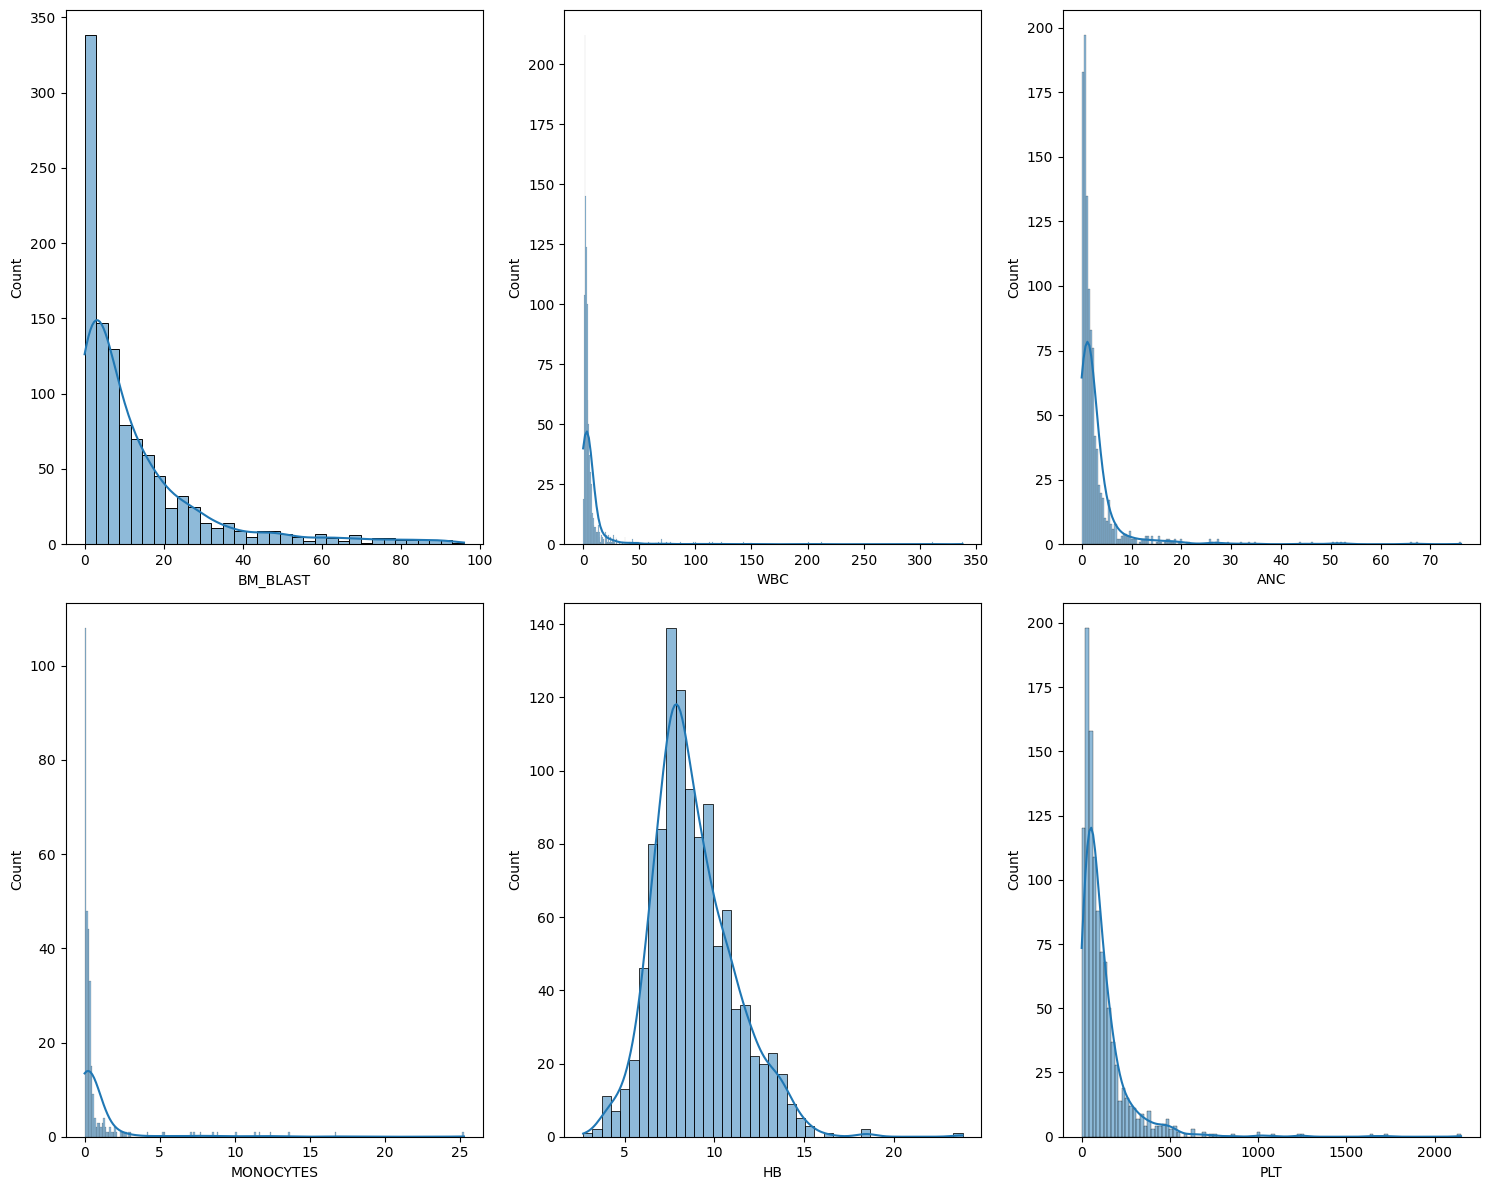

In [31]:
import math

col_int = [col for (col , dtype) in zip(cl_df.columns,cl_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]


num_cols = len(col_int)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize = (15,12))


for i, cols in enumerate(col_int , 1):
    plt.subplot(num_rows,3,i)
    sns.histplot(data = cl_df,x = cols,kde = True)
plt.tight_layout()
plt.show()

In [32]:

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.impute import IterativeImputer
import category_encoders as ce




def map_lambda(df , col , new_name , function , return_type):
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: function(x) , return_dtype=return_type)
        .alias(new_name)
    )
    
    return df


def map_row(df, col1, col2, new_name, function, return_type):
    return df.with_columns(
        pl.struct([col1, col2]).map_elements(
            lambda row: function(row[col1], row[col2]), return_dtype=return_type
        ).alias(new_name)
    )




def binary_encoder(df, cl_lst):
    df_pd = df.to_pandas()
    
    encoder = ce.BinaryEncoder(cols=cl_lst)
    df_encoded = encoder.fit_transform(df_pd)
    
    return pl.from_pandas(df_encoded)



def strategy_imputation(df , strategy):
    df = df.fill_null(strategy=strategy)

    return df





def imputation_null_values(df, column_list, estimator=None):
    """
    Impute missing values using iterative imputation.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns with missing values
    column_list : list
        List of column names to impute
    estimator : object, default=None
        Estimator for IterativeImputer (defaults to RandomForestRegressor if None)

    Returns:
    --------
    pl.DataFrame
        DataFrame with imputed values

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for imputation: {', '.join(missing_columns)}")

    # Check if there are any null values to impute
    null_counts = {col: df.select(pl.col(col).is_null().sum())[0, 0] for col in column_list}
    if sum(null_counts.values()) == 0:
        return df  # No nulls to impute

    try:
        # Select subset of dataframe
        sub_df = df.select(column_list)

        # Convert to pandas
        sub_pd = sub_df.to_pandas()
        

        # Apply imputation
        imputer = IterativeImputer(estimator=estimator, random_state=42)
        imputed_data = imputer.fit_transform(sub_pd)

        # Convert back to polars
        imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

        # Replace nulls in original dataframe
        df = df.with_columns([imputed_pl[col].alias(col) for col in column_list])

        return df
    except Exception as e:
        raise ValueError(f"Error during imputation: {str(e)}")



def iqr_method(df , cl_lst):

    for (index , cl )  in enumerate(cl_lst):
        q1 = df.select(pl.col(cl).quantile(0.25)).item()
        q3 = df.select(pl.col(cl).quantile(0.75)).item()
        
        iqr = q3 - q1
        
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        
        # Winsorisation : capped values
        df = df.with_columns(
            pl.when(pl.col(cl) < lower_bound).then(lower_bound)
            .when(pl.col(cl) > upper_bound).then(upper_bound)
            .otherwise(pl.col(cl))
            .alias(cl)
        )
        
        
        
    return df


def z_score(df, cl_list):
    
    for cl in cl_list:
        mean = df.select(pl.col(cl).mean()).item()
        std = df.select(pl.col(cl).std()).item()

        # Définir les bornes avec Z = ±3
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std

        # Appliquer la winsorisation
        df = df.with_columns(
            pl.when(pl.col(cl) < lower_bound).then(lower_bound)
            .when(pl.col(cl) > upper_bound).then(upper_bound)
            .otherwise(pl.col(cl))
            .alias(cl)
        )

    return df

def min_max_normalization(df, column_list):
    """
    Apply min-max normalization to specified columns.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns to normalize
    column_list : list
        List of column names to normalize

    Returns:
    --------
    pl.DataFrame
        DataFrame with normalized columns

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for normalization: {', '.join(missing_columns)}")

    try:
        for col in column_list:
            min_val = df[col].min()
            max_val = df[col].max()

            # Avoid division by zero
            if min_val == max_val:
                df = df.with_columns(
                    pl.lit(0.5).alias(col)
                )
            else:
                df = df.with_columns(
                    ((pl.col(col) - min_val)/(max_val - min_val)).alias(col)
                )

        return df
    except Exception as e:
        raise ValueError(f"Error during min-max normalization: {str(e)}")

def Z_scaling(df , col):
    mean = df[col].mean()
    std = df[col].std()
    
    
    df = df.with_columns(
        ((pl.col(col) - mean)/(std)).alias(f"{col}_Z_score")
    )
    
    return df
    

In [33]:
def cyto_regex(cyto, reg_expr):
    """
    Check if a cytogenetic string matches a regular expression pattern.
    
    Parameters:
    -----------
    cyto : str
        Cytogenetic string to check
    reg_expr : str
        Regular expression pattern to match
        
    Returns:
    --------
    int
        1 if pattern matches, 0 otherwise
    """
    if cyto is not None:
        if re.search(reg_expr, cyto, re.IGNORECASE):
            return 1
    return 0


def anomaly_number(cytogenetic, keyword, regex_expr):
    """
    Extract chromosome number from cytogenetic anomaly description.
    
    Parameters:
    -----------
    cytogenetic : str
        Cytogenetic string to analyze
    keyword : str
        Keyword to check for (e.g., 'del', 'inv')
    regex_expr : str
        Regular expression to extract chromosome number
        
    Returns:
    --------
    int
        Chromosome number or -1 if not found
    """
    if cyto_regex(cytogenetic, keyword):
        del_nbr = re.findall(regex_expr, cytogenetic)
        if del_nbr: 
            return int(del_nbr[0])
    return -1 


def transloc_nbr(cytogenetic):
    """
    Extract chromosome numbers involved in translocation.
    
    Parameters:
    -----------
    cytogenetic : str
        Cytogenetic string to analyze
        
    Returns:
    --------
    list
        List of chromosome numbers involved in translocation or [-1] if none found
    """
    if cyto_regex(cytogenetic, 't'):
        trans_nbr = re.findall(r"t\((\d+);(\d+)\)", cytogenetic)
        if trans_nbr:
            flat = [int(x) for tup in trans_nbr for x in tup]
            return flat
    return [-1]


def is_complex(cyto):
    """
    Check if a karyotype is complex (has 3 or more abnormalities).
    
    Parameters:
    -----------
    cyto : str
        Cytogenetic string to analyze
        
    Returns:
    --------
    int
        1 if complex karyotype, 0 otherwise
    """
    return 1 if len(re.findall(r"\+|\-|del|t|inv|add|i\(", cyto)) >= 3 else 0


def is_missing_cytogenetics(df):
    """
    Replace null values in all columns with -1.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame to process
        
    Returns:
    --------
    pl.DataFrame
        DataFrame with null values replaced by -1
    """
    for col in df.columns:
        null_count = df.select(pl.col(col).is_null().sum())[0, 0]
        if null_count > 0:
            df = df.with_columns(
                pl.when(pl.col(col).is_null()).then(-1).otherwise(pl.col(col)).alias(col)
            )
            
    return df


def is_male_karyotype(karyotype, male_code='46,xy'):
    """
    Check if a karyotype represents a male (XY).
    
    Parameters:
    -----------
    karyotype : str
        Karyotype string to check
    male_code : str, default='46,xy'
        Code that identifies a male karyotype
        
    Returns:
    --------
    int
        1 if male karyotype, 0 otherwise
    """
    return 1 if karyotype and male_code in karyotype.lower() else 0


def is_female_karyotype(karyotype, female_code='46,xx'):
    """
    Check if a karyotype represents a female (XX).
    
    Parameters:
    -----------
    karyotype : str
        Karyotype string to check
    female_code : str, default='46,xx'
        Code that identifies a female karyotype
        
    Returns:
    --------
    int
        1 if female karyotype, 0 otherwise
    """
    return 1 if karyotype and female_code in karyotype.lower() else 0


def is_a_Man(df, col):
    """
    Add a column indicating if each row represents a male karyotype.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing karyotype data
    col : str
        Column name containing karyotype information
        
    Returns:
    --------
    pl.DataFrame
        DataFrame with added 'is_a_Man' column
    """
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: is_male_karyotype(x))
        .alias("is_a_Man")
    )
    
    return df


def is_a_Female(df, col):
    """
    Add a column indicating if each row represents a female karyotype.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing karyotype data
    col : str
        Column name containing karyotype information
        
    Returns:
    --------
    pl.DataFrame
        DataFrame with added 'is_a_Female' column
    """
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: is_female_karyotype(x))
        .alias("is_a_Female")
    )
    
    return df

In [34]:
from sklearn.tree import DecisionTreeRegressor


def process_clinical_data(cl_df):
    """
    Process clinical data for cytogenetic analysis.
    
    Parameters:
    -----------
    cl_df : pl.DataFrame
        DataFrame containing clinical data
        
    Returns:
    --------
    pl.DataFrame
        Processed DataFrame with additional features
    """
    # Validate input
    if not isinstance(cl_df, pl.DataFrame):
        raise TypeError("Input must be a polars DataFrame")
    
    # Handle outliers in clinical measurements
    cl_df = iqr_method(cl_df, ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"])
    
    # Imputation of missing values for clinical measurements
    cl_df = imputation_null_values(cl_df, ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"], estimator=DecisionTreeRegressor())
    
    # # Encode categorical variables
    # cl_df = binary_encoder(cl_df, ["CENTER"])
    
    # Gender identification from karyotype
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_a_Man", is_male_karyotype, pl.Int32)
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_a_Female", is_female_karyotype, pl.Int32)
    
    # Cytogenetic abnormalities detection
    
    # Deletion anomalies
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_deletion_anomaly", lambda x: cyto_regex(x, reg_expr=r'del'), pl.Int32)
    
    # Inversion anomalies
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_inversion_anomaly", lambda x: cyto_regex(x, reg_expr=r'inv'), pl.Int32)
    
    # Addition anomalies
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_added_anomaly", lambda x: cyto_regex(x, reg_expr=r'add'), pl.Int32)
    
    # Common chromosomal abnormalities
    
    # Down Syndrome (Trisomy 21)
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_down_syndrome", lambda x: cyto_regex(x, reg_expr=r'\+21'), pl.Int32)
    
    # Monosomy 7
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_monosomy", lambda x: cyto_regex(x, reg_expr=r'\-7'), pl.Int32)
    
    # Partial deletion of 7th chromosome
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_7_deleted", lambda x: cyto_regex(x, reg_expr=r'del\(7\)'), pl.Int32)
    
    # Trisomy 8
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_trisomy_8", lambda x: cyto_regex(x, reg_expr=r'\+8'), pl.Int32)
    
    # Other structural abnormalities
    
    # Isochromosome
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "iso_chromosome", lambda x: cyto_regex(x, reg_expr=r"i\(\d+\)|iso\(\d.+\)"), pl.Int64)
    
    # Derived chromosome
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_derived_chromosome", lambda x: cyto_regex(x, reg_expr=r"der\(\d+\)"), pl.Int64)
    
    # Sex chromosome abnormalities
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_lost_sex_chromosome", lambda x: cyto_regex(x, reg_expr=r"\-[xy]"), pl.Int64)
    
    # Numerical abnormalities
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_added_chromsome", lambda x: cyto_regex(x, reg_expr=r",\+\d+"), pl.Int64)
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_deleted_chromsome", lambda x: cyto_regex(x, reg_expr=r",\-\d+"), pl.Int64)
    
    # Insertion abnormalities
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_inserted_chromsome", lambda x: cyto_regex(x, reg_expr=r"ins"), pl.Int64)
    
    # Translocation anomaly
    cl_df = map_lambda(cl_df , "CYTOGENETICS" , "is_translocated_anomaly" , lambda x: cyto_regex(x ,reg_expr=r't' ) , pl.Int32)
    
    # Complex karyotype detection
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_complex_karyo", is_complex, pl.Int64)
    
    # Handle missing cytogenetic data
    cl_df = is_missing_cytogenetics(cl_df)
    
    # Normalize clinical measurements
    col_to_normalize = ["BM_BLAST", "WBC", "ANC", "HB", "PLT"]
    cl_df = min_max_normalization(cl_df, col_to_normalize)
    
    return cl_df

In [35]:
cl_df = process_clinical_data(cl_df)

cl_df


c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_normal_cyto,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo
str,str,f64,f64,f64,f64,f64,f64,str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i64,i64,i64,i64,i64,i64,i32,i64
"""KYW1""","""KYW""",1.0,0.329356,0.101295,0.0324,0.393519,0.15894,"""47,xy,+x,del(9)(q?)[15]/47,xy,…",0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
"""KYW2""","""KYW""",0.886076,0.30358,0.214197,0.0311,0.615741,0.10596,"""46,xy,der(3)?t(3;11)(q26.2;q23…",0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,1
"""KYW3""","""KYW""",1.0,1.0,1.0,0.93675,0.828704,0.082781,"""47,xx,+8""",0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
"""KYW4""","""KYW""",1.0,0.529833,0.354663,0.93675,0.430556,0.145695,"""normal""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""KYW5""","""KYW""",0.050633,0.115513,0.127478,0.03,0.486111,0.089404,"""43,xy,dic(5;17)(q11.2;p11.2),-…",0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KYW1189""","""KYW""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,"""-1""",0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
"""KYW1190""","""KYW""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,"""-1""",0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
"""KYW1191""","""KYW""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,"""-1""",0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [36]:
col_to_drop = [col for col , dtype in zip(cl_df.columns , cl_df.dtypes) if dtype == pl.Utf8]

col_to_drop.remove("ID")

cl_df = cl_df.drop(col_to_drop)

In [37]:
cl_df

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_normal_cyto,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo
str,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i64,i64,i64,i64,i64,i64,i32,i64
"""KYW1""",1.0,0.329356,0.101295,0.0324,0.393519,0.15894,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
"""KYW2""",0.886076,0.30358,0.214197,0.0311,0.615741,0.10596,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,1
"""KYW3""",1.0,1.0,1.0,0.93675,0.828704,0.082781,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
"""KYW4""",1.0,0.529833,0.354663,0.93675,0.430556,0.145695,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""KYW5""",0.050633,0.115513,0.127478,0.03,0.486111,0.089404,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KYW1189""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
"""KYW1190""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
"""KYW1191""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [38]:
pre_processed_clinical = cl_df.write_csv("../data/processed/X_test/clinical_test_preprocess.csv")